In [26]:
#Bai03
import math

def create_board(n):
    return [['_'] * n for _ in range(n)]

def check_winner(board, k):
    n = len(board)

    for i in range(n):
        for j in range(n):
            if board[i][j] == '_':
                continue

            player = board[i][j]

            # ngang
            if j + k <= n and all(board[i][j+x] == player for x in range(k)):
                return player

            # dọc
            if i + k <= n and all(board[i+x][j] == player for x in range(k)):
                return player

            # chéo chính
            if i + k <= n and j + k <= n and all(board[i+x][j+x] == player for x in range(k)):
                return player

            # chéo phụ
            if i + k <= n and j - k + 1 >= 0 and all(board[i+x][j-x] == player for x in range(k)):
                return player

    return None

def evaluate(board, k):
    winner = check_winner(board, k)
    if winner == 'X':
        return 100
    elif winner == 'O':
        return -100
    return 0

# FIX: nếu bàn trống → đánh giữa
def get_moves(board):
    n = len(board)
    moves = []

    # kiểm tra bàn trống
    empty = True
    for row in board:
        if 'X' in row or 'O' in row:
            empty = False
            break

    if empty:
        return [(n//2, n//2)]

    # chỉ lấy ô gần quân
    directions = [-1, 0, 1]
    move_set = set()

    for i in range(n):
        for j in range(n):
            if board[i][j] != '_':
                for dx in directions:
                    for dy in directions:
                        ni, nj = i + dx, j + dy
                        if 0 <= ni < n and 0 <= nj < n and board[ni][nj] == '_':
                            move_set.add((ni, nj))

    return list(move_set)

def minimax(board, depth, max_depth, is_max, k):
    score = evaluate(board, k)

    if abs(score) == 100 or depth == max_depth:
        return score

    moves = get_moves(board)

    if is_max:
        best = -math.inf
        for (i, j) in moves:
            board[i][j] = 'X'
            val = minimax(board, depth+1, max_depth, False, k)
            board[i][j] = '_'
            best = max(best, val)
        return best
    else:
        best = math.inf
        for (i, j) in moves:
            board[i][j] = 'O'
            val = minimax(board, depth+1, max_depth, True, k)
            board[i][j] = '_'
            best = min(best, val)
        return best

def find_best_move(board, k, max_depth=2):
    best_val = -math.inf
    best_move = None

    for (i, j) in get_moves(board):
        board[i][j] = 'X'
        move_val = minimax(board, 0, max_depth, False, k)
        board[i][j] = '_'

        if move_val > best_val:
            best_val = move_val
            best_move = (i, j)

    return best_move


# ===== TEST =====
n = 5
k = 3  # hoặc 5 nếu chơi caro chuẩn

board = create_board(n)

move = find_best_move(board, k, max_depth=2)
print("Best move:", move)

Best move: (2, 2)


In [27]:
#Bai04
import math

def create_board(n):
    return [['_'] * n for _ in range(n)]

# ===== CHECK WIN =====
def check_winner(board, k):
    n = len(board)

    for i in range(n):
        for j in range(n):
            if board[i][j] == '_':
                continue

            player = board[i][j]

            # ngang
            if j + k <= n and all(board[i][j+x] == player for x in range(k)):
                return player

            # dọc
            if i + k <= n and all(board[i+x][j] == player for x in range(k)):
                return player

            # chéo chính
            if i + k <= n and j + k <= n and all(board[i+x][j+x] == player for x in range(k)):
                return player

            # chéo phụ
            if i + k <= n and j - k + 1 >= 0 and all(board[i+x][j-x] == player for x in range(k)):
                return player

    return None

# ===== HEURISTIC =====
def evaluate(board, k):
    winner = check_winner(board, k)
    if winner == 'X':
        return 1000
    elif winner == 'O':
        return -1000
    return 0

# ===== MOVE GENERATION (QUAN TRỌNG) =====
def get_moves(board):
    n = len(board)

    # nếu bàn trống → đánh giữa
    empty = True
    for row in board:
        if 'X' in row or 'O' in row:
            empty = False
            break

    if empty:
        return [(n//2, n//2)]

    moves = set()
    directions = [-1, 0, 1]

    for i in range(n):
        for j in range(n):
            if board[i][j] != '_':
                for dx in directions:
                    for dy in directions:
                        ni, nj = i + dx, j + dy
                        if 0 <= ni < n and 0 <= nj < n and board[ni][nj] == '_':
                            moves.add((ni, nj))

    return list(moves)

# ===== ALPHA-BETA =====
def alphabeta(board, depth, max_depth, alpha, beta, is_max, k):
    score = evaluate(board, k)

    # dừng
    if abs(score) == 1000 or depth == max_depth:
        return score

    moves = get_moves(board)

    if is_max:  # X
        best = -math.inf
        for (i, j) in moves:
            board[i][j] = 'X'

            val = alphabeta(board, depth+1, max_depth, alpha, beta, False, k)

            board[i][j] = '_'
            best = max(best, val)
            alpha = max(alpha, best)

            # cắt tỉa
            if beta <= alpha:
                break

        return best

    else:  # O
        best = math.inf
        for (i, j) in moves:
            board[i][j] = 'O'

            val = alphabeta(board, depth+1, max_depth, alpha, beta, True, k)

            board[i][j] = '_'
            best = min(best, val)
            beta = min(beta, best)

            # cắt tỉa
            if beta <= alpha:
                break

        return best

# ===== BEST MOVE =====
def find_best_move(board, k, max_depth=2):
    best_val = -math.inf
    best_move = None

    for (i, j) in get_moves(board):
        board[i][j] = 'X'

        move_val = alphabeta(board, 0, max_depth, -math.inf, math.inf, False, k)

        board[i][j] = '_'

        if move_val > best_val:
            best_val = move_val
            best_move = (i, j)

    return best_move


# ===== TEST =====
n = 5
k = 3   # hoặc 5 nếu chơi caro chuẩn

board = create_board(n)

move = find_best_move(board, k, max_depth=2)
print("Best move:", move)

Best move: (2, 2)


In [34]:
#Bai05
import chess
import math

# ====== PIECE VALUE ======
piece_value = {
    chess.PAWN: 100,
    chess.KNIGHT: 320,
    chess.BISHOP: 330,
    chess.ROOK: 500,
    chess.QUEEN: 900,
    chess.KING: 20000
}

# ====== POSITION BONUS (trung tâm + phát triển quân) ======
center_squares = [chess.D4, chess.E4, chess.D5, chess.E5]

def evaluate(board):
    if board.is_checkmate():
        if board.turn:  # trắng bị chiếu hết
            return -99999
        else:
            return 99999

    if board.is_stalemate():
        return 0

    score = 0

    for piece_type in piece_value:
        score += len(board.pieces(piece_type, chess.WHITE)) * piece_value[piece_type]
        score -= len(board.pieces(piece_type, chess.BLACK)) * piece_value[piece_type]

    # 🎯 bonus trung tâm
    for sq in center_squares:
        piece = board.piece_at(sq)
        if piece:
            if piece.color == chess.WHITE:
                score += 20
            else:
                score -= 20

    return score


# ====== MOVE ORDERING (rất quan trọng cho alpha-beta) ======
def order_moves(board, moves):
    def move_score(move):
        score = 0

        if board.is_capture(move):
            score += 1000  # ăn quân ưu tiên cao

        if move.promotion:
            score += 800  # phong hậu

        if move.to_square in center_squares:
            score += 50  # chiếm trung tâm

        return score

    return sorted(moves, key=move_score, reverse=True)


# ====== ALPHA BETA ======
def alphabeta(board, depth, alpha, beta, maximizing):
    if depth == 0 or board.is_game_over():
        return evaluate(board)

    moves = list(board.legal_moves)
    moves = order_moves(board, moves)

    if maximizing:
        max_eval = -math.inf

        for move in moves:
            board.push(move)

            eval = alphabeta(board, depth - 1, alpha, beta, False)

            board.pop()

            max_eval = max(max_eval, eval)
            alpha = max(alpha, eval)

            if beta <= alpha:
                break

        return max_eval

    else:
        min_eval = math.inf

        for move in moves:
            board.push(move)

            eval = alphabeta(board, depth - 1, alpha, beta, True)

            board.pop()

            min_eval = min(min_eval, eval)
            beta = min(beta, eval)

            if beta <= alpha:
                break

        return min_eval


# ====== TÌM NƯỚC ĐI TỐT NHẤT ======
def find_best_move(board, depth=3):
    best_move = None
    best_value = -math.inf

    moves = list(board.legal_moves)
    moves = order_moves(board, moves)

    for move in moves:
        board.push(move)

        value = alphabeta(board, depth - 1, -math.inf, math.inf, False)

        board.pop()

        if value > best_value:
            best_value = value
            best_move = move

    return best_move


# ====== TEST GAME ======
board = chess.Board()

print("Initial board:")
print(board)

move = find_best_move(board, depth=3)

print("\nBest move:", move)

Initial board:
r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N R

Best move: e2e4


In [ ]:
#Bai06
import tkinter as tk
from tkinter import messagebox

board = [["" for _ in range(3)] for _ in range(3)]
current_player = "X"
game_over = False

# ===== CHECK WIN =====
def check_winner():
    # hàng
    for i in range(3):
        if board[i][0] == board[i][1] == board[i][2] != "":
            return board[i][0]

    # cột
    for j in range(3):
        if board[0][j] == board[1][j] == board[2][j] != "":
            return board[0][j]

    # chéo
    if board[0][0] == board[1][1] == board[2][2] != "":
        return board[0][0]

    if board[0][2] == board[1][1] == board[2][0] != "":
        return board[0][2]

    return None


# ===== CHECK DRAW =====
def is_draw():
    for row in board:
        if "" in row:
            return False
    return True


# ===== CLICK CELL =====
def click(row, col):
    global current_player, game_over

    if game_over or board[row][col] != "":
        return

    board[row][col] = current_player
    buttons[row][col].config(text=current_player)

    winner = check_winner()

    if winner:
        game_over = True
        messagebox.showinfo("Game Over", f"Người thắng: {winner}")
        return

    if is_draw():
        game_over = True
        messagebox.showinfo("Game Over", "Hòa!")
        return

    # đổi lượt
    current_player = "O" if current_player == "X" else "X"


# ===== RESET GAME =====
def reset_game():
    global board, current_player, game_over

    board = [["" for _ in range(3)] for _ in range(3)]
    current_player = "X"
    game_over = False

    for i in range(3):
        for j in range(3):
            buttons[i][j].config(text="")


# ===== GUI =====
root = tk.Tk()
root.title("Tic Tac Toe")

buttons = [[None for _ in range(3)] for _ in range(3)]

for i in range(3):
    for j in range(3):
        btn = tk.Button(
            root,
            text="",
            font=("Arial", 30),
            width=5,
            height=2,
            command=lambda r=i, c=j: click(r, c)
        )
        btn.grid(row=i, column=j)
        buttons[i][j] = btn

# reset button
reset_btn = tk.Button(root, text="Reset", font=("Arial", 15), command=reset_game)
reset_btn.grid(row=3, column=0, columnspan=3, sticky="we")

root.mainloop()


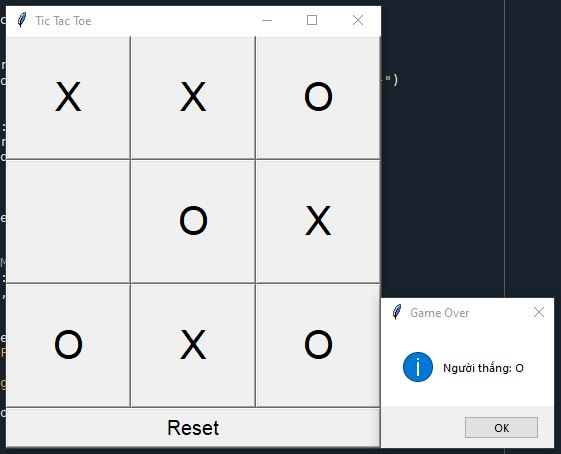